In [4]:
"""
Phase 3: ML Model Training

Two models:
  1. Grade Predictor     → Regression  (Random Forest vs XGBoost)
  2. Pass/Fail Predictor → Classification (Random Forest vs XGBoost)
  - Load preprocessed data from Phase 2
  - Train both model types
  - Evaluate on validation set
  - Select best model per task
  - Run ONCE at the end on test set for final honest score
  - Save models
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.model_selection import cross_val_score

try:
    from xgboost import XGBRegressor, XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    print("XGBoost not installed.")
    XGBOOST_AVAILABLE = False


In [5]:
print("=" * 70)
print("PHASE 3: ML MODEL TRAINING")
print("=" * 70)

# STEP 1: Load Preprocessed Data
print("\nStep 1: Loading preprocessed data...")

with open('preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_val   = data['X_val']
X_test  = data['X_test']

y_grade_train = data['y_grade_train']
y_grade_val   = data['y_grade_val']
y_grade_test  = data['y_grade_test']

y_pass_train  = data['y_pass_train']
y_pass_val    = data['y_pass_val']
y_pass_test   = data['y_pass_test']

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples:       {len(X_test)}")
print(f"Features:           {list(X_train.columns)}")
print(f"Fail rate (train):  {(1 - y_pass_train.mean())*100:.1f}%")


PHASE 3: ML MODEL TRAINING

Step 1: Loading preprocessed data...
Training samples:   3500
Validation samples: 750
Test samples:       750
Features:           ['total_study_hours', 'avg_session_length', 'study_sessions_per_week', 'focus_ratio', 'late_night_study_ratio', 'days_until_deadline_avg', 'video_completion_rate', 'practice_problem_attempts', 'forum_participation', 'study_streak_days', 'study_efficiency', 'procrastination_penalty']
Fail rate (train):  19.9%


In [9]:
# PART A: REGRESSION — Predict Final Grade (0–100)
print("\n" + "=" * 70)
print("PART A: REGRESSION — Predicting Final Grade")
print("=" * 70)

# Helperfunc: evaluate a regression model
def evaluate_regressor(model, X_tr, y_tr, X_v, y_v, name):
    """
    Fits a regressor, prints train + val metrics, returns val metrics.

    MAE  → Mean Absolute Error: average grade prediction error in points
    RMSE → Root Mean Squared Error: penalises large errors more than MAE
    R²   → Coefficient of determination: 1.0 = perfect, 0.0 = predicts mean
    """
    model.fit(X_tr, y_tr)

    train_pred = model.predict(X_tr)
    val_pred   = model.predict(X_v)

    results = {
        'model':      model,
        'name':       name,
        'train_mae':  mean_absolute_error(y_tr, train_pred),
        'val_mae':    mean_absolute_error(y_v, val_pred),
        'train_rmse': np.sqrt(mean_squared_error(y_tr, train_pred)),
        'val_rmse':   np.sqrt(mean_squared_error(y_v, val_pred)),
        'train_r2':   r2_score(y_tr, train_pred),
        'val_r2':     r2_score(y_v, val_pred),
        'val_pred':   val_pred
    }

    # Overfitting gap: if val_mae >> train_mae, model is overfitting
    gap = results['val_mae'] - results['train_mae']
    overfit_flag = "Possible overfit" if gap > 3 else "Healthy gap"

    print(f"\n  [{name}]")
    print(f"    Train MAE:  {results['train_mae']:.2f} pts  |  Val MAE:  {results['val_mae']:.2f} pts  ({overfit_flag})")
    print(f"    Train RMSE: {results['train_rmse']:.2f} pts  |  Val RMSE: {results['val_rmse']:.2f} pts")
    print(f"    Train R²:   {results['train_r2']:.3f}       |  Val R²:   {results['val_r2']:.3f}")

    return results


PART A: REGRESSION — Predicting Final Grade


In [10]:
# Model A1: Random Forest Regressor
# n_estimators=200: 200 trees (more = stable but slower)
# max_depth=8: limit tree depth to prevent memorisation
# min_samples_leaf=5: each leaf must cover ≥5 students (prevents tiny splits)
print("\nTraining regression models...")

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)
rf_reg_results = evaluate_regressor(rf_reg, X_train, y_grade_train, X_val, y_grade_val, "RandomForest")


Training regression models...

  [RandomForest]
    Train MAE:  6.32 pts  |  Val MAE:  7.84 pts  (Healthy gap)
    Train RMSE: 7.90 pts  |  Val RMSE: 9.72 pts
    Train R²:   0.602       |  Val R²:   0.402


In [ ]:
#Model A2: XGBoost Regressor
if XGBOOST_AVAILABLE:
    xgb_reg = XGBRegressor(
        n_estimators=200,
        max_depth=4,        # XGBoost needs shallower trees than RF
        learning_rate=0.05, # Small steps: better generalisation
        subsample=0.8,      # Each tree sees 80% of data (reduces overfitting)
        colsample_bytree=0.8, # Each tree sees 80% of features
        random_state=42,
        verbosity=0
    )
    xgb_reg_results = evaluate_regressor(xgb_reg, X_train, y_grade_train, X_val, y_grade_val, "XGBoost")
    reg_results = [rf_reg_results, xgb_reg_results]
else:
    reg_results = [rf_reg_results]


  [XGBoost]
    Train MAE:  6.24 pts  |  Val MAE:  7.65 pts  (✓ Healthy gap)
    Train RMSE: 7.77 pts  |  Val RMSE: 9.46 pts
    Train R²:   0.615       |  Val R²:   0.433


In [ ]:
#Select best regressor (lowest val MAE)
best_reg_result = min(reg_results, key=lambda r: r['val_mae'])
best_reg_model  = best_reg_result['model']
print(f"\n Best regressor: {best_reg_result['name']} (Val MAE = {best_reg_result['val_mae']:.2f})")

# Cross-validation on best model (more reliable than single val split)
# cv=5 : 5-fold cross-validation on training data
# Gives a confidence interval on performance
cv_scores = cross_val_score(
    best_reg_model, X_train, y_grade_train,
    cv=5, scoring='neg_mean_absolute_error'
)
cv_mae = -cv_scores  # sklearn returns negative MAE
print(f"\n  Cross-validation MAE (5-fold, training set):")
print(f"    Mean: {cv_mae.mean():.2f} ± {cv_mae.std():.2f} points")


 Best regressor: XGBoost (Val MAE = 7.65)

  Cross-validation MAE (5-fold, training set):
    Mean: 7.76 ± 0.25 points


In [ ]:
# PART B: CLASSIFICATION — Predict Pass / Fail
print("\n" + "=" * 70)
print("PART B: CLASSIFICATION — Predicting Pass / Fail")
print("=" * 70)

# Helper: evaluate a classifier
def evaluate_classifier(model, X_tr, y_tr, X_v, y_v, name):
    """
    Fits a classifier, prints train + val metrics.

    Accuracy  : % of correct predictions (misleading with imbalance!)
    F1        : Harmonic mean of Precision & Recall (better for imbalance)
    ROC-AUC   : Area under ROC curve (1.0 = perfect, 0.5 = random)

    We focus on:
      - F1 for the FAIL class (class 0) → catching at-risk students
      - ROC-AUC : overall discrimination ability
    """
    model.fit(X_tr, y_tr)

    train_pred = model.predict(X_tr)
    val_pred   = model.predict(X_v)
    val_proba  = model.predict_proba(X_v)[:, 1]  # probability of PASS

    results = {
        'model':         model,
        'name':          name,
        'train_acc':     accuracy_score(y_tr, train_pred),
        'val_acc':       accuracy_score(y_v, val_pred),
        'val_f1_macro':  f1_score(y_v, val_pred, average='macro'),
        'val_f1_fail':   f1_score(y_v, val_pred, pos_label=0, average='binary'),
        'val_auc':       roc_auc_score(y_v, val_proba),
        'val_pred':      val_pred,
        'val_proba':     val_proba
    }

    print(f"\n  [{name}]")
    print(f"    Train Accuracy:  {results['train_acc']*100:.1f}%  |  Val Accuracy:  {results['val_acc']*100:.1f}%")
    print(f"    Val F1 (macro):  {results['val_f1_macro']:.3f}   |  Val F1 (fail): {results['val_f1_fail']:.3f}")
    print(f"    Val ROC-AUC:     {results['val_auc']:.3f}")

    # Print full classification report
    print(f"\n    Classification Report (Val):")
    report = classification_report(y_v, val_pred, target_names=['Fail', 'Pass'])
    for line in report.split('\n'):
        print(f"      {line}")

    return results


PART B: CLASSIFICATION — Predicting Pass / Fail


In [ ]:
# class_weight='balanced': automatically penalises missing the minority class
# Without this: model ignores failing students to maximise accuracy
# With this:    misclassifying a fail costs 4x more than misclassifying a pass
print("\nTraining classification models...")

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',  # handles 80/20 imbalance
    random_state=42
)
rf_clf_results = evaluate_classifier(rf_clf, X_train, y_pass_train, X_val, y_pass_val, "RandomForest")

if XGBOOST_AVAILABLE:
    # scale_pos_weight = ratio of negatives to positives
    # tells XGBoost to weight the minority class (fail) more
    neg = (y_pass_train == 0).sum()
    pos = (y_pass_train == 1).sum()
    scale = neg / pos  # ~0.24 here : minority class upweighted by4x

    xgb_clf = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale,
        random_state=42,
        verbosity=0,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    xgb_clf_results = evaluate_classifier(xgb_clf, X_train, y_pass_train, X_val, y_pass_val, "XGBoost")
    clf_results = [rf_clf_results, xgb_clf_results]
else:
    clf_results = [rf_clf_results]


Training classification models...

  [RandomForest]
    Train Accuracy:  87.0%  |  Val Accuracy:  79.3%
    Val F1 (macro):  0.694   |  Val F1 (fail): 0.520
    Val ROC-AUC:     0.810

    Classification Report (Val):
                    precision    recall  f1-score   support
      
              Fail       0.48      0.56      0.52       149
              Pass       0.89      0.85      0.87       601
      
          accuracy                           0.79       750
         macro avg       0.68      0.71      0.69       750
      weighted avg       0.81      0.79      0.80       750
      

  [XGBoost]
    Train Accuracy:  84.2%  |  Val Accuracy:  75.6%
    Val F1 (macro):  0.675   |  Val F1 (fail): 0.512
    Val ROC-AUC:     0.815

    Classification Report (Val):
                    precision    recall  f1-score   support
      
              Fail       0.42      0.64      0.51       149
              Pass       0.90      0.78      0.84       601
      
          accuracy         

In [ ]:
#Select best classifier (highest ROC-AUC on val)
best_clf_result = max(clf_results, key=lambda r: r['val_auc'])
best_clf_model  = best_clf_result['model']
print(f"\n Best classifier: {best_clf_result['name']} (Val AUC = {best_clf_result['val_auc']:.3f})")


 Best classifier: XGBoost (Val AUC = 0.815)


In [ ]:
# Retrain best models on Train + Validation before final test
print("\nRetraining best models on Train + Validation data...")

X_train_full = pd.concat([X_train, X_val])
y_grade_train_full = pd.concat([y_grade_train, y_grade_val])
y_pass_train_full  = pd.concat([y_pass_train, y_pass_val])

best_reg_model.fit(X_train_full, y_grade_train_full)
best_clf_model.fit(X_train_full, y_pass_train_full)



Retraining best models on Train + Validation data...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [ ]:
# Threshold Tuning (Validation Set ONLY)
print("\nTuning classification threshold (using validation set)...")

val_proba = best_clf_result['val_proba']

thresholds = np.linspace(0.1, 0.9, 81)

best_threshold = 0.5
best_f1_fail = 0

for t in thresholds:
    preds = (val_proba >= t).astype(int)
    f1 = f1_score(y_pass_val, preds, pos_label=0)

    if f1 > best_f1_fail:
        best_f1_fail = f1
        best_threshold = t

print(f"Best threshold (for FAIL F1): {best_threshold:.2f}")
print(f"Validation F1 (fail) at best threshold: {best_f1_fail:.3f}")


Tuning classification threshold (using validation set)...
Best threshold (for FAIL F1): 0.38
Validation F1 (fail) at best threshold: 0.547


In [ ]:
# STEP 2: FINAL TEST SET EVALUATION
print("\n" + "=" * 70)
print("STEP 2: FINAL TEST SET EVALUATION")
print("(We touch the test set ONCE — final honest scores)")
print("=" * 70)

#Regression on test
test_grade_pred = best_reg_model.predict(X_test)
test_mae  = mean_absolute_error(y_grade_test, test_grade_pred)
test_rmse = np.sqrt(mean_squared_error(y_grade_test, test_grade_pred))
test_r2   = r2_score(y_grade_test, test_grade_pred)

print(f"\nRegression — {best_reg_result['name']}")
print(f"  Test MAE:  {test_mae:.2f} points")
print(f"  Test RMSE: {test_rmse:.2f} points")
print(f"  Test R²:   {test_r2:.3f}")

#Classification on test
test_pass_proba = best_clf_model.predict_proba(X_test)[:, 1]
test_pass_pred  = (test_pass_proba >= best_threshold).astype(int)
test_acc  = accuracy_score(y_pass_test, test_pass_pred)
test_f1   = f1_score(y_pass_test, test_pass_pred, average='macro')
test_f1_fail = f1_score(y_pass_test, test_pass_pred, pos_label=0, average='binary')
test_auc  = roc_auc_score(y_pass_test, test_pass_proba)

print(f"\nClassification — {best_clf_result['name']}")
print(f"  Test Accuracy:  {test_acc*100:.1f}%")
print(f"  Test F1 Macro:  {test_f1:.3f}")
print(f"  Test F1 (Fail): {test_f1_fail:.3f}")
print(f"  Test ROC-AUC:   {test_auc:.3f}")

#Success criteria check
print("\n  Success Criteria Check:")
print(f"Grade MAE < 10 pts  (got {test_mae:.2f})")
print(f"Pass/Fail Acc > 85%  (got {test_acc*100:.1f}%)")
print(f"ROC-AUC > 0.85       (got {test_auc:.3f})")


STEP 2: FINAL TEST SET EVALUATION
(We touch the test set ONCE — final honest scores)

Regression — XGBoost
  Test MAE:  7.92 points
  Test RMSE: 9.90 points
  Test R²:   0.393

Classification — XGBoost
  Test Accuracy:  78.9%
  Test F1 Macro:  0.688
  Test F1 (Fail): 0.509
  Test ROC-AUC:   0.802

  Success Criteria Check:
Grade MAE < 10 pts  (got 7.92)
Pass/Fail Acc > 85%  (got 78.9%)
ROC-AUC > 0.85       (got 0.802)



Step 3: Generating evaluation plots...


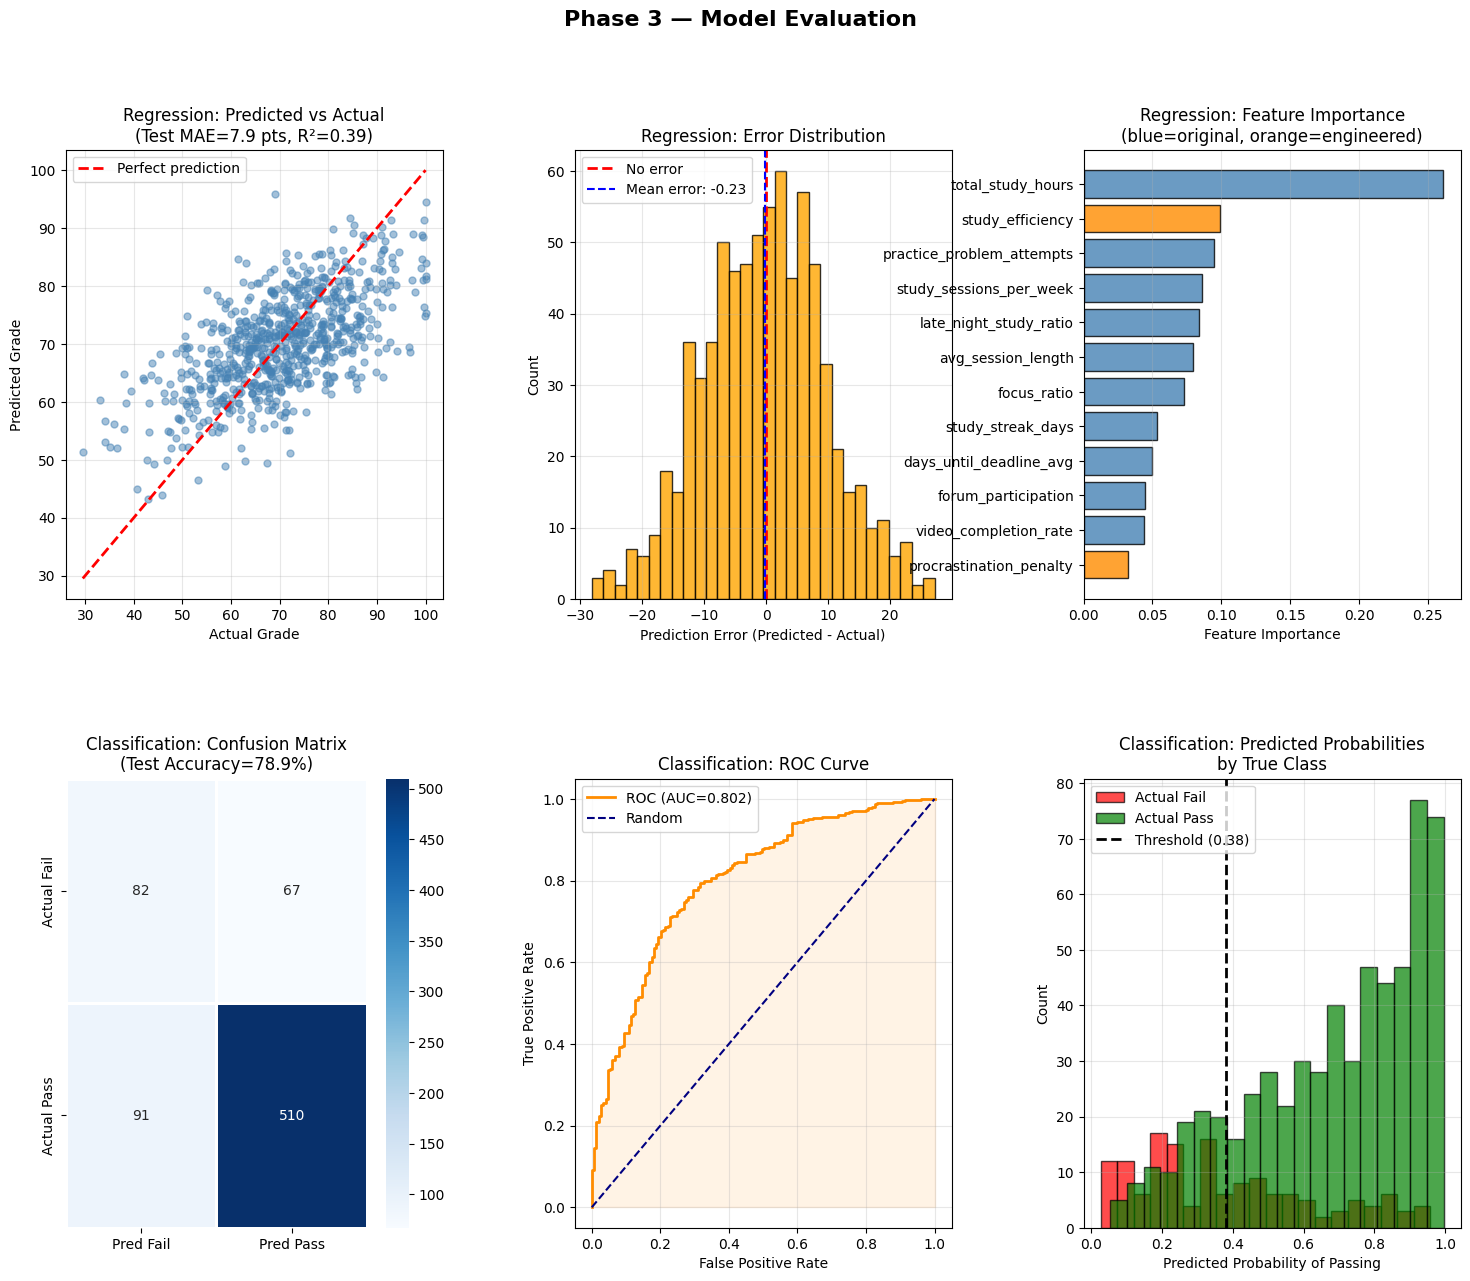

In [ ]:
# STEP 3: VISUALIZATIONS
print("\nStep 3: Generating evaluation plots...")

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('Phase 3 — Model Evaluation', fontsize=16, fontweight='bold')

# Plot 1: Predicted vs Actual Grade
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y_grade_test, test_grade_pred, alpha=0.5, s=25, color='steelblue')
min_g, max_g = y_grade_test.min(), y_grade_test.max()
ax1.plot([min_g, max_g], [min_g, max_g], 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual Grade')
ax1.set_ylabel('Predicted Grade')
ax1.set_title(f'Regression: Predicted vs Actual\n(Test MAE={test_mae:.1f} pts, R²={test_r2:.2f})')
ax1.legend()
ax1.grid(alpha=0.3)

#Plot 2: Prediction Error Distribution
ax2 = fig.add_subplot(gs[0, 1])
errors = test_grade_pred - y_grade_test
ax2.hist(errors, bins=30, edgecolor='black', alpha=0.8, color='orange')
ax2.axvline(0, color='red', linestyle='--', linewidth=2, label='No error')
ax2.axvline(errors.mean(), color='blue', linestyle='--',
            label=f'Mean error: {errors.mean():.2f}')
ax2.set_xlabel('Prediction Error (Predicted - Actual)')
ax2.set_ylabel('Count')
ax2.set_title('Regression: Error Distribution')
ax2.legend()
ax2.grid(alpha=0.3)

#Plot 3: Feature Importance (Regression)
ax3 = fig.add_subplot(gs[0, 2])
feat_names = list(X_train.columns)
importances = best_reg_model.feature_importances_
indices = np.argsort(importances)[::-1]
colors_bar = ['steelblue' if i < 10 else 'darkorange' for i in range(len(feat_names))]
bars = ax3.barh(
    [feat_names[i] for i in indices],
    [importances[i] for i in indices],
    color=[colors_bar[i] for i in indices],
    edgecolor='black', alpha=0.8
)
ax3.set_xlabel('Feature Importance')
ax3.set_title('Regression: Feature Importance\n(blue=original, orange=engineered)')
ax3.invert_yaxis()
ax3.grid(alpha=0.3, axis='x')

#Plot 4: Confusion Matrix
ax4 = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_pass_test, test_pass_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Pred Fail', 'Pred Pass'],
            yticklabels=['Actual Fail', 'Actual Pass'],
            linewidths=2)
ax4.set_title(f'Classification: Confusion Matrix\n(Test Accuracy={test_acc*100:.1f}%)')

#Plot 5: ROC Curve
ax5 = fig.add_subplot(gs[1, 1])
fpr, tpr, thresholds = roc_curve(y_pass_test, test_pass_proba)
ax5.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'ROC (AUC={test_auc:.3f})')
ax5.plot([0, 1], [0, 1], color='navy', linestyle='--', linewidth=1.5, label='Random')
ax5.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax5.set_xlabel('False Positive Rate')
ax5.set_ylabel('True Positive Rate')
ax5.set_title('Classification: ROC Curve')
ax5.legend()
ax5.grid(alpha=0.3)

#Plot 6: Predicted Probability Distribution by Class
ax6 = fig.add_subplot(gs[1, 2])
pass_proba_pass = test_pass_proba[y_pass_test == 1]
pass_proba_fail = test_pass_proba[y_pass_test == 0]
ax6.hist(pass_proba_fail, bins=20, alpha=0.7, color='red',   edgecolor='black', label='Actual Fail')
ax6.hist(pass_proba_pass, bins=20, alpha=0.7, color='green', edgecolor='black', label='Actual Pass')
ax6.axvline(best_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({best_threshold:.2f})')
ax6.set_xlabel('Predicted Probability of Passing')
ax6.set_ylabel('Count')
ax6.set_title('Classification: Predicted Probabilities\nby True Class')
ax6.legend()
ax6.grid(alpha=0.3)

In [ ]:
# STEP 4: Save Models
print("\nStep 4: Saving trained models...")
artifacts = {
    'regressor': best_reg_model,
    'classifier': best_clf_model,
    'scaler': data['scaler'],
    'feature_columns': list(X_train.columns),
    'regressor_name': best_reg_result['name'],
    'classifier_name': best_clf_result['name'],
    'best_threshold': best_threshold,
}

with open('trained_models.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Saved: trained_models.pkl")


Step 4: Saving trained models...
Saved: trained_models.pkl


In [54]:
print(f"""
  REGRESSION ({best_reg_result['name']})
  ─────────────────────────────
  Test MAE:   {test_mae:.2f} pts  (model is off by this many grade points on average)
  Test RMSE:  {test_rmse:.2f} pts
  Test R²:    {test_r2:.3f}       (explains {test_r2*100:.1f}% of grade variance)
  CV MAE:     {cv_mae.mean():.2f} ± {cv_mae.std():.2f} pts

  CLASSIFICATION ({best_clf_result['name']})
  ─────────────────────────────
  Test Accuracy:   {test_acc*100:.1f}%
  Test F1 (fail):  {test_f1_fail:.3f}   (← key metric for catching at-risk students)
  Test ROC-AUC:    {test_auc:.3f}
""")


  REGRESSION (XGBoost)
  ─────────────────────────────
  Test MAE:   7.92 pts  (model is off by this many grade points on average)
  Test RMSE:  9.90 pts
  Test R²:    0.393       (explains 39.3% of grade variance)
  CV MAE:     7.76 ± 0.25 pts

  CLASSIFICATION (XGBoost)
  ─────────────────────────────
  Test Accuracy:   78.9%
  Test F1 (fail):  0.509   (← key metric for catching at-risk students)
  Test ROC-AUC:    0.802

